In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

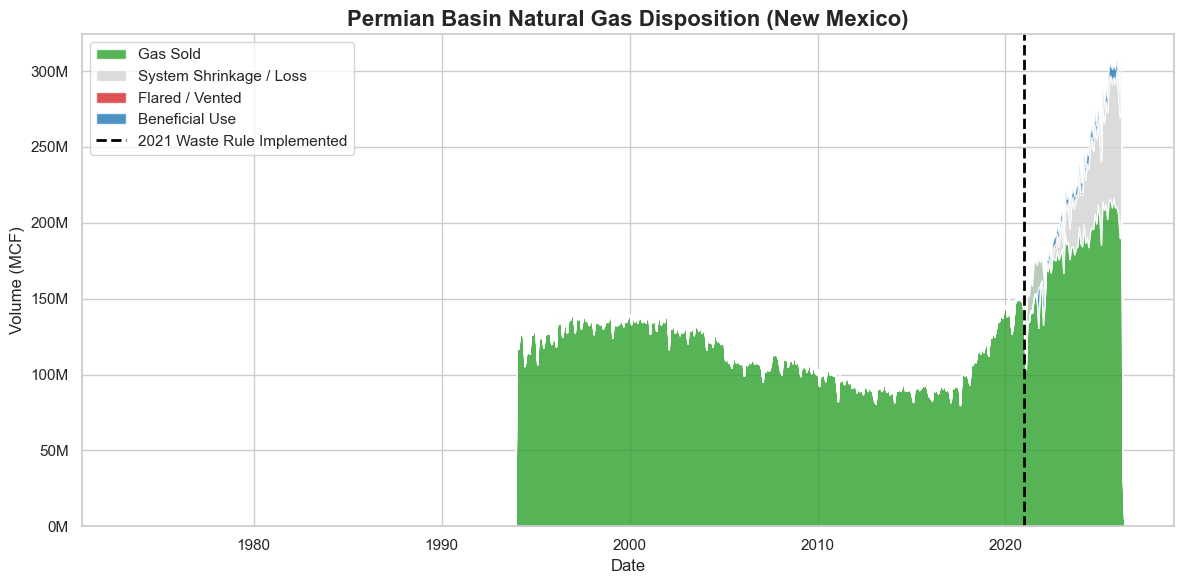

In [4]:
# Set up styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load Macro Basin Data
project_root = os.path.expanduser('~/work/projects/summer26-permian-flaring')
basin_df = pd.read_csv(os.path.join(project_root, 'data/processed/nm_basin_mass_balance_panel.csv'))

# Create a continuous datetime index for plotting
basin_df['Date'] = pd.to_datetime(basin_df[['Year', 'Month']].assign(DAY=1))
basin_df.set_index('Date', inplace=True)

# For plotting purposes, treat NaNs in the legacy era as 0 so the stacked area renders cleanly
plot_df = basin_df[['allocated_sales_mcf', 'waste_mcf', 'ben_use_mcf', 'shrinkage_mcf']].fillna(0)

# Create the stacked area plot
fig, ax = plt.subplots()
ax.stackplot(
    plot_df.index, 
    plot_df['allocated_sales_mcf'], 
    plot_df['shrinkage_mcf'], 
    plot_df['waste_mcf'], 
    plot_df['ben_use_mcf'],
    labels=['Gas Sold', 'System Shrinkage / Loss', 'Flared / Vented', 'Beneficial Use'],
    colors=['#2ca02c', '#d3d3d3', '#d62728', '#1f77b4'],
    alpha=0.8
)

ax.axvline(pd.to_datetime('2021-01-01'), color='black', linestyle='--', linewidth=2, label='2021 Waste Rule Implemented')
ax.set_title('Permian Basin Natural Gas Disposition (New Mexico)', fontsize=16, fontweight='bold')
ax.set_ylabel('Volume (MCF)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}M".format(int(x/1e6))))
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

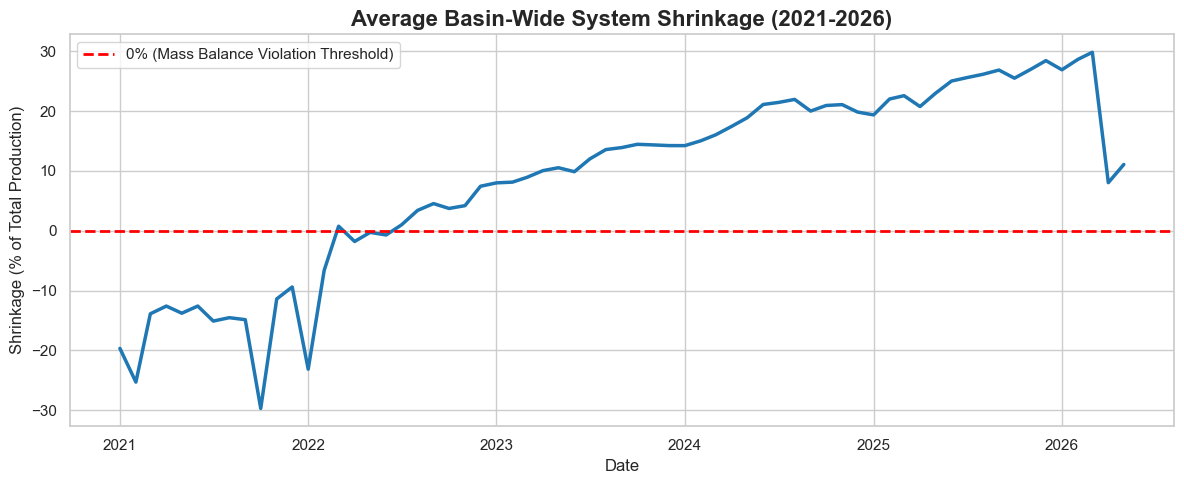

In [5]:
# Load Macro Basin Data
project_root = os.path.expanduser('~/work/projects/summer26-permian-flaring')
basin_df = pd.read_csv(os.path.join(project_root, 'data/processed/nm_basin_mass_balance_panel.csv'))

# Create Date column
basin_df['Date'] = pd.to_datetime(basin_df[['Year', 'Month']].assign(DAY=1))

# Plot Shrinkage Percentage
fig, ax = plt.subplots(figsize=(12, 5))

# We only plot 2021 onwards because legacy shrinkage is distorted by missing waste data
modern_era = basin_df[basin_df['Year'] >= 2021].copy()

sns.lineplot(data=modern_era, x='Date', y='shrinkage_pct', color='#1f77b4', linewidth=2.5, ax=ax)
ax.axhline(0, color='red', linestyle='--', linewidth=2, label='0% (Mass Balance Violation Threshold)')

ax.set_title('Average Basin-Wide System Shrinkage (2021-2026)', fontsize=16, fontweight='bold')
ax.set_ylabel('Shrinkage (% of Total Production)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.legend()

plt.tight_layout()
plt.show()

/var/folders/hm/5pdgvvfj333dyb862p7d7jn00000gn/T/ipykernel_97836/3749988781.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_flarers, x='flaring_intensity', y='Operator_ID', palette='Reds_r', ax=ax)


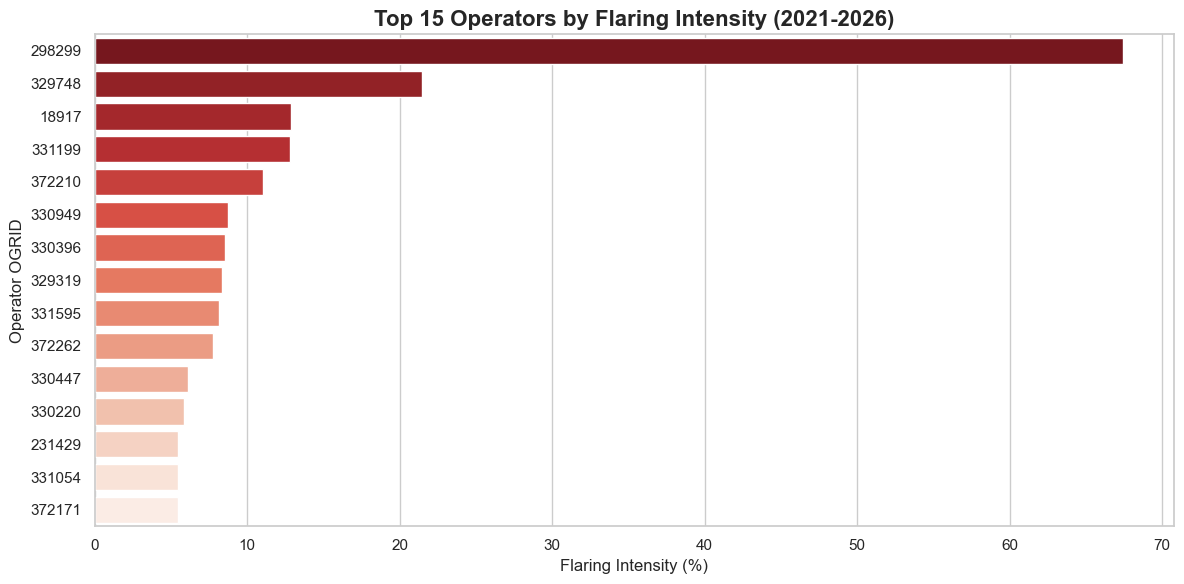

In [6]:
# Load Operator Data
project_root = os.path.expanduser('~/work/projects/summer26-permian-flaring')
op_df = pd.read_csv(os.path.join(project_root, 'data/processed/nm_operator_mass_balance_panel.csv'))

# Filter for the modern era
op_modern = op_df[op_df['Year'] >= 2021].copy()

# Aggregate totals per operator across the entire 2021-2026 timeline
agg_op = op_modern.groupby('Operator_ID')[['gas_vol', 'waste_mcf']].sum().reset_index()

# Filter out extremely small operators (e.g., must have produced at least 1,000,000 MCF total)
agg_op = agg_op[agg_op['gas_vol'] > 1000000].copy()

# Recalculate true intensity across the aggregated volumes
agg_op['flaring_intensity'] = (agg_op['waste_mcf'] / agg_op['gas_vol']) * 100

# Sort and take top 15
top_flarers = agg_op.sort_values('flaring_intensity', ascending=False).head(15)
top_flarers['Operator_ID'] = top_flarers['Operator_ID'].astype(str) # For categorical plotting

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_flarers, x='flaring_intensity', y='Operator_ID', palette='Reds_r', ax=ax)

ax.set_title('Top 15 Operators by Flaring Intensity (2021-2026)', fontsize=16, fontweight='bold')
ax.set_xlabel('Flaring Intensity (%)', fontsize=12)
ax.set_ylabel('Operator OGRID', fontsize=12)

plt.tight_layout()
plt.show()

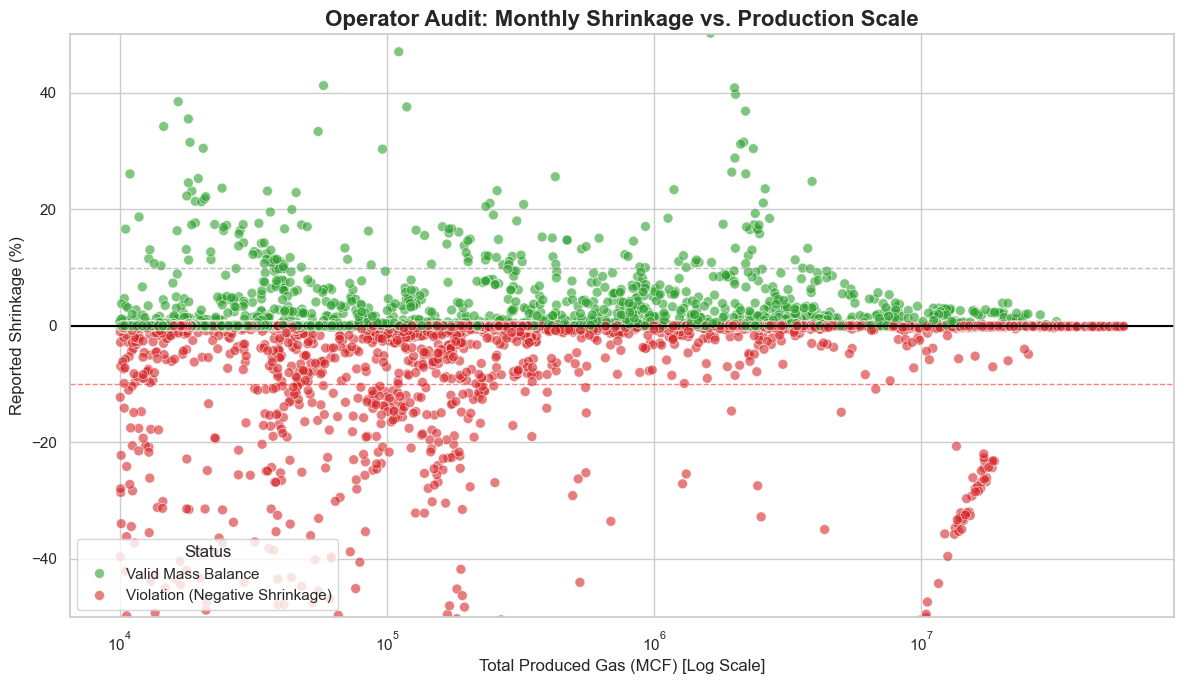

In [7]:
# Load Operator Data
project_root = os.path.expanduser('~/work/projects/summer26-permian-flaring')
op_df = pd.read_csv(os.path.join(project_root, 'data/processed/nm_operator_mass_balance_panel.csv'))

modern_op = op_df[op_df['Year'] >= 2021].copy()

# We only plot significant producing months to eliminate zero-division noise
plot_scatter = modern_op[modern_op['gas_vol'] > 10000].copy()

fig, ax = plt.subplots(figsize=(12, 7))

# Scatter plot: x is production scale (log), y is shrinkage
sns.scatterplot(
    data=plot_scatter, 
    x='gas_vol', 
    y='shrinkage_pct', 
    hue='mass_balance_violation', 
    palette={False: '#2ca02c', True: '#d62728'},
    alpha=0.6,
    s=50,
    ax=ax
)

ax.set_xscale('log')
ax.axhline(0, color='black', linestyle='-', linewidth=1.5)
ax.axhline(-10, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(10, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Limit Y axis to clip extreme infinity outliers
ax.set_ylim(-50, 50) 

ax.set_title('Operator Audit: Monthly Shrinkage vs. Production Scale', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Produced Gas (MCF) [Log Scale]', fontsize=12)
ax.set_ylabel('Reported Shrinkage (%)', fontsize=12)

# Update legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Valid Mass Balance', 'Violation (Negative Shrinkage)'], title='Status', loc='lower left')

plt.tight_layout()
plt.show()